# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [12]:
%load_ext IPython.extensions.autoreload
%autoreload 2

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [13]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [14]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


In [15]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


In [16]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


## Cargar datos fuente de entrenamiento


In [17]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [18]:
REGENERATE_MODEL = True


In [19]:
src_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_rating_array_boolean"
dst_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_boolean"
dst_path_boolean = os.path.join(dst_dir_boolean, "dataset_training.parquet")


In [20]:
from src.utils.models import BinaryModel


In [21]:
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")


In [ ]:
binary_model.s(
    spark, src_dir_boolean, target_columns=[b"rating_boolean"], shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


Files count: 10
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00001-15487876-b67d-48fd-aba5-4075e7093fb3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00000-15487876-b67d-48fd-aba5-4075e7093fb3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00002-15487876-b67d-48fd-aba5-4075e7093fb3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00003-15487876-b67d-48fd-aba5-4075e7093fb3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00004-15487876-b67d-48fd-aba5-4075e7093fb3-c000.snappy.parquet
Reading file: /mnt/d/Maestría

## Crear modelo de predicción


In [23]:
binary_model.create_model()


<Sequential name=sequential, built=True>

In [28]:
binary_model.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       102,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,356 (1.12 MB)

 Trainable params: 146,177 (571.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 146,179 (571.02 KB)

In [24]:
if True:
    history_model_binary = binary_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1761528786.236442 1209762 service.cc:146] XLA service 0x7c5f880d0070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761528786.236469 1209762 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-10-26 20:33:06.262222: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-26 20:33:06.428369: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


      8/Unknown 16s 24ms/step - accuracy: 0.5103 - loss: 0.7506

I0000 00:00:1761528787.852538 1209762 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   1812/Unknown 81s 36ms/step - accuracy: 0.6904 - loss: 0.6875

...

2025-10-26 21:18:33.642648: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9504970038499432827
2025-10-26 21:18:33.642689: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 5033057428958795968


1812/1812 ━━━━━━━━━━━━━━━━━━━━ 149s 81ms/step - accuracy: 0.9707 - loss: 0.0671 - val_accuracy: 0.9825 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 20/20
1811/1812 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9708 - loss: 0.0682

2025-10-26 21:19:43.452050: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9504970038499432827
2025-10-26 21:19:43.452089: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 5033057428958795968



Epoch 20: val_loss did not improve from 0.04053
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 143s 78ms/step - accuracy: 0.9717 - loss: 0.0650 - val_accuracy: 0.9831 - val_loss: 0.0420 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 19.


2025-10-26 21:20:57.104936: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 9504970038499432827
2025-10-26 21:20:57.104976: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 5033057428958795968


2025/10/26 21:21:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/26 21:21:01 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/26 21:21:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


3d22f578699344afbf70825e7d74c9dc
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_model.png


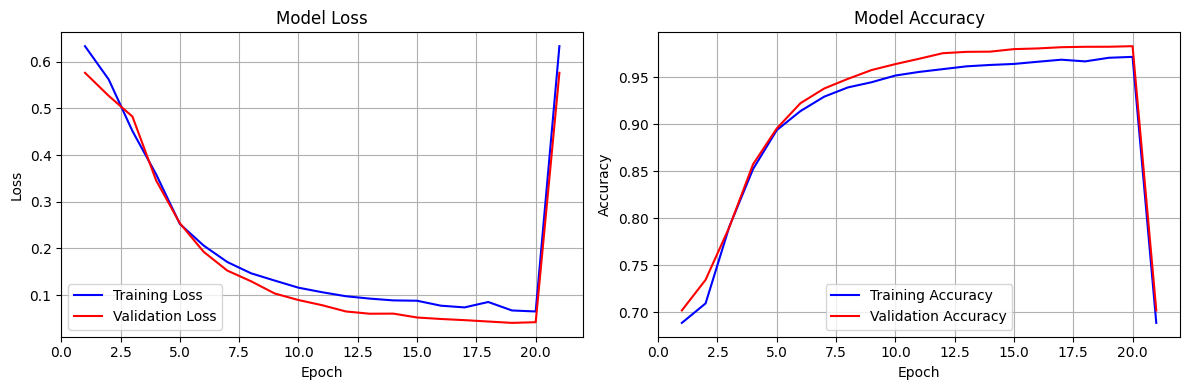

In [25]:
if True:
    for name, model in [
        ("binary_model", binary_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [26]:
from src.utils.models import BinaryModel
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
binary_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [27]:
binary_model.list_available_models()



Available Model Versions (filtered by: binary_model)

1. Run ID: 3d22f578699344afbf70825e7d74c9dc
   Run Name: binary_model_401features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-27 02:21:00.431000+00:00
   End Time: 2025-10-27 02:21:14.596000+00:00
   Metrics: Loss: 0.0650, Val Loss: 0.0420, Accuracy: 0.9717, Val Accuracy: 0.9831

2. Run ID: 195df4651b0e4630bb7a59963e15babe
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 01:24:18.123000+00:00
   End Time: 2025-10-20 01:24:32.448000+00:00
   Metrics: Loss: 0.5044, Val Loss: 0.6257, Accuracy: 0.7702, Val Accuracy: 0.7181

3. Run ID: da3b31aaa4664d86a48d473d0d937d68
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 18:27:54.745000+00:00
   End Time: 2025-10-19 18:28:08.397000+00:00
   Metrics: Loss: 0.0442, Val Loss: 0.0161, Accuracy: 0.9912, Val Accuracy: 1.0000

4. Run ID: a37b31c6482c44ce9b6feece646ba2cf
   Run Name